In [39]:
# Title: Deep Learning Solutions and Estimation for Structural Corporate Finance Models
import os, sys, math, json, itertools, time
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

tfd, tfb = tfp.distributions, tfp.bijectors
tf.keras.utils.set_random_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__, "TFP:", tfp.__version__)

TensorFlow: 2.13.0 TFP: 0.21.0


# Part 1 #

**(a) Maliar-Style Deep Residual Formulations**

In [40]:
# TF2 implementation: Strebulaev & Whited (2012) Sec 3.1, eqs (3.9)-(3.10)
# Maliar-style deep residual method: Bellman residual minimization

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import tensorflow as tf

DTYPE = tf.float32

# -----------------------------
# 1) Model parameters
# -----------------------------
class Params:
    # preferences / discounting
    r = 0.04
    beta = 1.0 / (1.0 + r)

    # technology
    theta = 0.7          # profit curvature
    delta = 0.15         # depreciation
    phi = 0.01           # adj cost coefficient (quadratic in I)

    # shock process: log z' = rho log z + eps', eps' ~ N(0, sigma^2)
    rho = 0.7
    sigma_eps = 0.15     # std dev of eps'

    # numerical stabilization bounds
    k_min = 1e-6
    k_max = 200.0
    z_min = 1e-4
    z_max = 50.0

P = Params()

# -----------------------------
# 2) Shock transition sampler (eq 3.9)
# -----------------------------
@tf.function
def sample_z_next(z, n_mc, rho, sigma_eps):
    """
    z: [B,1]
    returns z_next: [B, n_mc]
    """
    z = tf.clip_by_value(z, P.z_min, P.z_max)
    logz = tf.math.log(z)  # [B,1]
    eps = tf.random.normal([tf.shape(z)[0], n_mc], mean=0.0, stddev=sigma_eps, dtype=DTYPE)
    logz_next = rho * logz + eps  # broadcast to [B, n_mc]
    z_next = tf.exp(logz_next)
    z_next = tf.clip_by_value(z_next, P.z_min, P.z_max)
    return z_next

# -----------------------------
# 3) Payoff components
# -----------------------------
@tf.function
def profit_pi(k, z, theta):
    k = tf.clip_by_value(k, P.k_min, P.k_max)
    z = tf.clip_by_value(z, P.z_min, P.z_max)
    return z * tf.pow(k, theta)

@tf.function
def adj_cost(I, phi):
    return 0.5 * phi * tf.square(I)

# -----------------------------
# 4) Networks: value V_theta(k,z) and policy k'_phi(k,z) >= 0
# -----------------------------
def make_mlp(out_dim, hidden=(128, 128), act="tanh", name="mlp"):
    layers = []
    for h in hidden:
        layers.append(tf.keras.layers.Dense(h, activation=act))
    layers.append(tf.keras.layers.Dense(out_dim, activation=None))
    return tf.keras.Sequential(layers, name=name)

class ValueNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.body = make_mlp(1, hidden=(256, 256), act="tanh", name="V_body")

    @tf.function
    def call(self, k, z):
        x = tf.concat([k, z], axis=1)
        return self.body(x)  # unconstrained scalar

class PolicyNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.body = make_mlp(1, hidden=(256, 256), act="tanh", name="Kp_body")

    @tf.function
    def call(self, k, z):
        x = tf.concat([k, z], axis=1)
        raw = self.body(x)
        # enforce k' >= 0
        kp = tf.nn.softplus(raw)  # smooth, strictly positive
        # optional: cap
        kp = tf.clip_by_value(kp, 0.0, P.k_max)
        return kp

Vnet = ValueNet()
Pnet = PolicyNet()

# -----------------------------
# 5) State sampler for training
# -----------------------------
def sample_states(batch_size, k_log_range=(-2.0, 4.5), z_log_range=(-1.0, 1.0), seed=None):
    """
    Samples (k,z) roughly log-uniform over ranges.
    """
    rng = np.random.default_rng(seed)
    logk = rng.uniform(k_log_range[0], k_log_range[1], size=(batch_size, 1)).astype(np.float32)
    logz = rng.uniform(z_log_range[0], z_log_range[1], size=(batch_size, 1)).astype(np.float32)
    k = np.exp(logk)
    z = np.exp(logz)
    k = np.clip(k, P.k_min, P.k_max)
    z = np.clip(z, P.z_min, P.z_max)
    return tf.convert_to_tensor(k, DTYPE), tf.convert_to_tensor(z, DTYPE)

# -----------------------------
# 6) Bellman residual and loss
# -----------------------------
@tf.function
def bellman_residual(k, z, n_mc):
    """
    Computes residual R = V(k,z) - [pi - psi(I) - I + beta E V(k', z')]
    """
    beta = tf.constant(P.beta, DTYPE)

    V = Vnet(k, z)                         # [B,1]
    kp = Pnet(k, z)                        # [B,1]
    I = kp - (1.0 - P.delta) * k           # [B,1]

    flow = profit_pi(k, z, P.theta) - adj_cost(I, P.phi) - I  # [B,1]

    z_next = sample_z_next(z, n_mc, P.rho, P.sigma_eps)       # [B, n_mc]
    # broadcast kp to [B, n_mc]
    kp_mc = tf.tile(kp, [1, n_mc])
    # flatten for value eval
    V_next = Vnet(tf.reshape(kp_mc, [-1, 1]), tf.reshape(z_next, [-1, 1]))
    V_next = tf.reshape(V_next, [-1, n_mc])                   # [B, n_mc]
    EV_next = tf.reduce_mean(V_next, axis=1, keepdims=True)   # [B,1]

    target = flow + beta * EV_next
    R = V - target
    return R, {
        "V": V, "kp": kp, "I": I, "flow": flow, "EV_next": EV_next, "target": target
    }

@tf.function
def loss_fn(k, z, n_mc, l2_reg=1e-8):
    R, aux = bellman_residual(k, z, n_mc)
    mse = tf.reduce_mean(tf.square(R))
    # small weight decay
    l2 = tf.add_n([tf.nn.l2_loss(v) for v in Vnet.trainable_variables + Pnet.trainable_variables])
    return mse + l2_reg * l2, mse, aux

# -----------------------------
# 7) Training loop
# -----------------------------
def train(
    steps=10000,
    batch_size=4096,
    n_mc_train=16,
    lr=2e-4,
    grad_clip=1.0,
    print_every=500,
    seed=123
):
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    rng = np.random.default_rng(seed)

    for step in range(1, steps + 1):
        k, z = sample_states(batch_size, seed=rng.integers(1, 1_000_000))

        with tf.GradientTape() as tape:
            L, mse, aux = loss_fn(k, z, n_mc_train)

        vars_ = Vnet.trainable_variables + Pnet.trainable_variables
        grads = tape.gradient(L, vars_)
        grads, _ = tf.clip_by_global_norm(grads, grad_clip)
        opt.apply_gradients(zip(grads, vars_))

        if step % print_every == 0 or step == 1:
            # quick diagnostics
            kp = aux["kp"]
            I = aux["I"]
            print(
                f"step {step:6d} | loss {float(L):.4e} | bellman_mse {float(mse):.4e} "
                f"| kp mean {float(tf.reduce_mean(kp)):.3f} | I mean {float(tf.reduce_mean(I)):.3f}"
            )

# -----------------------------
# 8) Main
# -----------------------------
if __name__ == "__main__":
    tf.random.set_seed(0)
    np.random.seed(0)

    # build networks by calling once
    k0, z0 = sample_states(4, seed=0)
    _ = Vnet(k0, z0); _ = Pnet(k0, z0)

    train()

step      1 | loss 6.6170e+02 | bellman_mse 6.6170e+02 | kp mean 0.714 | I mean -11.194
step    500 | loss 1.2913e+01 | bellman_mse 1.2913e+01 | kp mean 4.688 | I mean -6.965
step   1000 | loss 3.0781e+00 | bellman_mse 3.0781e+00 | kp mean 2.065 | I mean -9.572
step   1500 | loss 1.1723e+00 | bellman_mse 1.1723e+00 | kp mean 1.637 | I mean -10.077
step   2000 | loss 7.4446e-01 | bellman_mse 7.4446e-01 | kp mean 1.513 | I mean -10.391
step   2500 | loss 1.7155e+00 | bellman_mse 1.7155e+00 | kp mean 1.481 | I mean -10.232
step   3000 | loss 5.0251e-01 | bellman_mse 5.0251e-01 | kp mean 1.329 | I mean -10.657
step   3500 | loss 4.8678e-01 | bellman_mse 4.8677e-01 | kp mean 1.280 | I mean -10.578
step   4000 | loss 5.0131e-01 | bellman_mse 5.0131e-01 | kp mean 1.224 | I mean -10.134
step   4500 | loss 5.0936e-01 | bellman_mse 5.0935e-01 | kp mean 1.148 | I mean -10.407
step   5000 | loss 2.7568e-01 | bellman_mse 2.7568e-01 | kp mean 1.121 | I mean -10.648
step   5500 | loss 2.3314e-01 | be

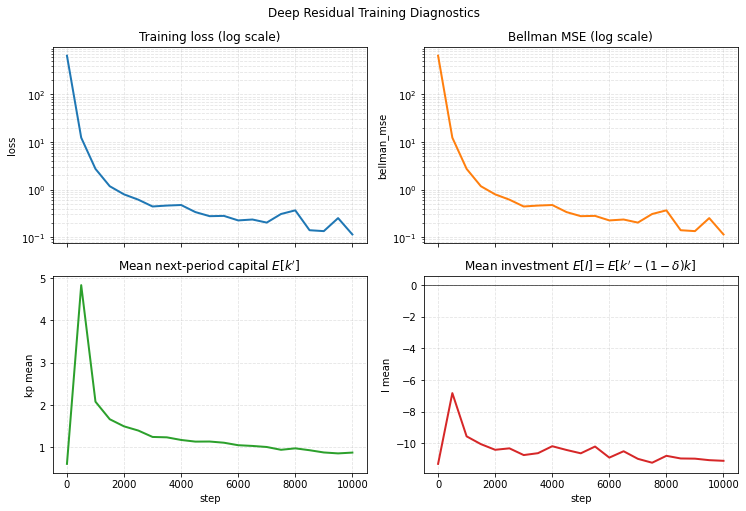

In [41]:
# plot_training_log.py
import os
import re
import numpy as np
import matplotlib.pyplot as plt

LOG_TEXT = r"""
step      1 | loss 6.4822e+02 | bellman_mse 6.4822e+02 | kp mean 0.613 | I mean -11.295
step    500 | loss 1.2319e+01 | bellman_mse 1.2319e+01 | kp mean 4.830 | I mean -6.824
step   1000 | loss 2.7204e+00 | bellman_mse 2.7204e+00 | kp mean 2.080 | I mean -9.557
step   1500 | loss 1.1757e+00 | bellman_mse 1.1757e+00 | kp mean 1.666 | I mean -10.048
step   2000 | loss 7.9337e-01 | bellman_mse 7.9337e-01 | kp mean 1.498 | I mean -10.406
step   2500 | loss 6.1358e-01 | bellman_mse 6.1358e-01 | kp mean 1.399 | I mean -10.314
step   3000 | loss 4.4144e-01 | bellman_mse 4.4143e-01 | kp mean 1.248 | I mean -10.739
step   3500 | loss 4.6129e-01 | bellman_mse 4.6129e-01 | kp mean 1.239 | I mean -10.620
step   4000 | loss 4.7398e-01 | bellman_mse 4.7397e-01 | kp mean 1.177 | I mean -10.180
step   4500 | loss 3.3673e-01 | bellman_mse 3.3672e-01 | kp mean 1.138 | I mean -10.417
step   5000 | loss 2.7629e-01 | bellman_mse 2.7629e-01 | kp mean 1.140 | I mean -10.628
step   5500 | loss 2.8005e-01 | bellman_mse 2.8004e-01 | kp mean 1.112 | I mean -10.200
step   6000 | loss 2.2496e-01 | bellman_mse 2.2495e-01 | kp mean 1.053 | I mean -10.900
step   6500 | loss 2.3499e-01 | bellman_mse 2.3498e-01 | kp mean 1.036 | I mean -10.498
step   7000 | loss 2.0244e-01 | bellman_mse 2.0244e-01 | kp mean 1.011 | I mean -10.977
step   7500 | loss 3.0683e-01 | bellman_mse 3.0682e-01 | kp mean 0.945 | I mean -11.223
step   8000 | loss 3.6614e-01 | bellman_mse 3.6614e-01 | kp mean 0.979 | I mean -10.786
step   8500 | loss 1.4000e-01 | bellman_mse 1.3999e-01 | kp mean 0.935 | I mean -10.954
step   9000 | loss 1.3404e-01 | bellman_mse 1.3403e-01 | kp mean 0.882 | I mean -10.966
step   9500 | loss 2.5152e-01 | bellman_mse 2.5151e-01 | kp mean 0.860 | I mean -11.061
step  10000 | loss 1.1403e-01 | bellman_mse 1.1402e-01 | kp mean 0.879 | I mean -11.102
""".strip()

def parse_log(text: str):
    # captures: step, loss, bellman_mse, kp mean, I mean
    pat = re.compile(
        r"step\s+(\d+)\s+\|\s+loss\s+([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)\s+\|"
        r"\s+bellman_mse\s+([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)\s+\|"
        r"\s+kp mean\s+([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)\s+\|"
        r"\s+I mean\s+([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)"
    )
    rows = []
    for line in text.splitlines():
        m = pat.search(line.strip())
        if m:
            step = int(m.group(1))
            loss = float(m.group(2))
            bell = float(m.group(3))
            kp = float(m.group(4))
            I = float(m.group(5))
            rows.append((step, loss, bell, kp, I))
    if not rows:
        raise ValueError("No rows parsed. Check log format.")
    arr = np.array(rows, dtype=float)
    return {
        "step": arr[:, 0],
        "loss": arr[:, 1],
        "bellman_mse": arr[:, 2],
        "kp_mean": arr[:, 3],
        "I_mean": arr[:, 4],
    }

def main():
    os.makedirs("fig", exist_ok=True)
    d = parse_log(LOG_TEXT)

    step = d["step"]
    loss = d["loss"]
    bell = d["bellman_mse"]
    kp = d["kp_mean"]
    I = d["I_mean"]

    fig, axs = plt.subplots(2, 2, figsize=(10.5, 7.2), sharex=True)
    axs = axs.ravel()

    axs[0].plot(step, loss, lw=2)
    axs[0].set_yscale("log")
    axs[0].set_title("Training loss (log scale)")
    axs[0].set_ylabel("loss")
    axs[0].grid(True, which="both", ls="--", alpha=0.35)

    axs[1].plot(step, bell, lw=2, color="tab:orange")
    axs[1].set_yscale("log")
    axs[1].set_title("Bellman MSE (log scale)")
    axs[1].set_ylabel("bellman_mse")
    axs[1].grid(True, which="both", ls="--", alpha=0.35)

    axs[2].plot(step, kp, lw=2, color="tab:green")
    axs[2].set_title(r"Mean next-period capital $E[k']$")
    axs[2].set_xlabel("step")
    axs[2].set_ylabel("kp mean")
    axs[2].grid(True, ls="--", alpha=0.35)

    axs[3].plot(step, I, lw=2, color="tab:red")
    axs[3].axhline(0.0, color="black", lw=1, alpha=0.6)
    axs[3].set_title(r"Mean investment $E[I]=E[k'-(1-\delta)k]$")
    axs[3].set_xlabel("step")
    axs[3].set_ylabel("I mean")
    axs[3].grid(True, ls="--", alpha=0.35)

    fig.suptitle("Deep Residual Training Diagnostics", y=0.98)
    fig.tight_layout()
    plt.show()
    #fig.savefig("fig/training_diagnostics.pdf")
    #fig.savefig("fig/training_diagnostics.png", dpi=200)
    #plt.close(fig)

    #print("Saved: fig/training_diagnostics.pdf and .png")

if __name__ == "__main__":
    main()

**(d) Extension to models with risky debt (Section 3.6)**

step      1 | total 4.152e+02 | bell 4.151e+02 | price 4.665e-01 | mean p_def 0.538 | mean rtilde 0.760
step    500 | total 3.358e+00 | bell 2.864e+00 | price 2.471e+00 | mean p_def 0.472 | mean rtilde 0.020
step   1000 | total 6.573e-01 | bell 5.638e-01 | price 4.676e-01 | mean p_def 0.457 | mean rtilde 0.004
step   1500 | total 3.012e-01 | bell 2.607e-01 | price 2.028e-01 | mean p_def 0.439 | mean rtilde 0.009
step   2000 | total 2.195e-01 | bell 1.885e-01 | price 1.550e-01 | mean p_def 0.455 | mean rtilde 0.010
step   2500 | total 1.666e-01 | bell 1.452e-01 | price 1.072e-01 | mean p_def 0.445 | mean rtilde 0.011
step   3000 | total 1.745e-01 | bell 1.539e-01 | price 1.031e-01 | mean p_def 0.459 | mean rtilde 0.011
step   3500 | total 2.519e-01 | bell 2.394e-01 | price 6.233e-02 | mean p_def 0.456 | mean rtilde 0.014
step   4000 | total 1.989e-01 | bell 1.854e-01 | price 6.765e-02 | mean p_def 0.438 | mean rtilde 0.013
step   4500 | total 2.235e-01 | bell 2.165e-01 | price 3.490e-02

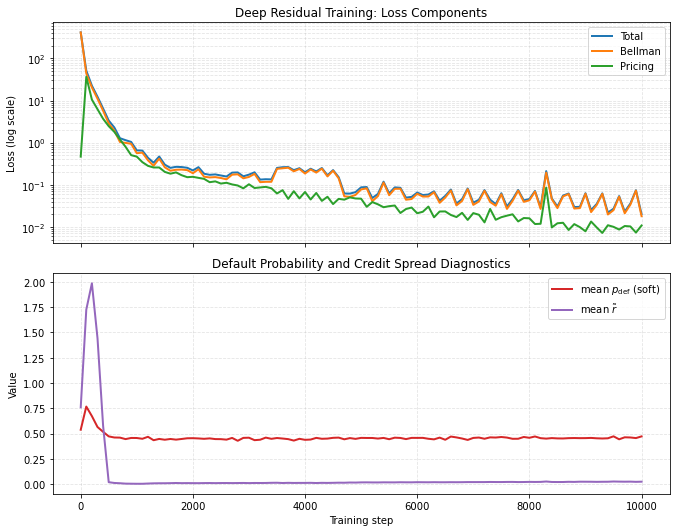

In [42]:
# sec36_risky_debt_demo_tf_with_plots.py
# TF2 demo + logging + plotting
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import csv
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

DTYPE = tf.float32

class Params:
    r = 0.02
    beta = 1.0 / (1.0 + r)

    theta = 0.7
    delta = 0.15
    phi = 0.01

    rho = 0.7
    sigma_eps = 0.15

    tau = 0.2          # corporate tax (synthetic)
    alpha = 0.2        # deadweight default cost fraction in recovery

    k_min = 1e-6
    k_max = 200.0
    z_min = 1e-4
    z_max = 50.0

P = Params()

def make_mlp(out_dim, hidden=(256, 256), act="tanh"):
    return tf.keras.Sequential(
        [tf.keras.layers.Dense(h, activation=act) for h in hidden] +
        [tf.keras.layers.Dense(out_dim, activation=None)]
    )

class VNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.mlp = make_mlp(1)

    @tf.function
    def call(self, k, b, z):
        x = tf.concat([k, b, z], axis=1)
        return self.mlp(x)

class PolicyNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.mlp = make_mlp(2)

    @tf.function
    def call(self, k, b, z):
        x = tf.concat([k, b, z], axis=1)
        out = self.mlp(x)
        kp = tf.nn.softplus(out[:, 0:1])
        bp = out[:, 1:2]  # can be +/- (debt or cash)
        kp = tf.clip_by_value(kp, 0.0, P.k_max)
        return kp, bp

class RateNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.mlp = make_mlp(1)

    @tf.function
    def call(self, z, kp, bp):
        x = tf.concat([z, kp, bp], axis=1)
        raw = self.mlp(x)
        # ensure 1 + rtilde > 0
        rtilde = tf.nn.softplus(raw) - 1e-3
        return rtilde

V = VNet()
Pol = PolicyNet()
Rate = RateNet()

@tf.function
def sample_z_next(z, n_mc):
    z = tf.clip_by_value(z, P.z_min, P.z_max)
    eps = tf.random.normal([tf.shape(z)[0], n_mc], 0.0, P.sigma_eps, dtype=DTYPE)
    logz_next = P.rho * tf.math.log(z) + eps
    z_next = tf.exp(logz_next)
    return tf.clip_by_value(z_next, P.z_min, P.z_max)

@tf.function
def pi(k, z):
    return tf.clip_by_value(z, P.z_min, P.z_max) * tf.pow(tf.clip_by_value(k, P.k_min, P.k_max), P.theta)

@tf.function
def psi(I):
    return 0.5 * P.phi * tf.square(I)

def sample_states(B, seed=0):
    rng = np.random.default_rng(seed)
    k = np.exp(rng.uniform(-2.0, 4.5, size=(B, 1))).astype(np.float32)
    z = np.exp(rng.uniform(-1.0, 1.0, size=(B, 1))).astype(np.float32)
    b = rng.uniform(-20.0, 50.0, size=(B, 1)).astype(np.float32)  # cash to debt
    k = np.clip(k, P.k_min, P.k_max)
    z = np.clip(z, P.z_min, P.z_max)
    return tf.constant(k), tf.constant(b), tf.constant(z)

@tf.function
def residuals(k, b, z, n_mc):
    beta = tf.constant(P.beta, DTYPE)

    V_now = V(k, b, z)                  # [B,1]
    kp, bp = Pol(k, b, z)               # [B,1],[B,1]
    rtilde = Rate(z, kp, bp)            # [B,1]

    I = kp - (1.0 - P.delta) * k

    # Synthetic sources/uses:
    flow = (1.0 - P.tau) * pi(k, z) - I - psi(I) + bp / (1.0 + rtilde) - b

    # next shocks
    z_next = sample_z_next(z, n_mc)     # [B,M]
    kp_mc = tf.tile(kp, [1, n_mc])      # [B,M]
    bp_mc = tf.tile(bp, [1, n_mc])      # [B,M]
    V_next = V(tf.reshape(kp_mc, [-1, 1]), tf.reshape(bp_mc, [-1, 1]), tf.reshape(z_next, [-1, 1]))
    V_next = tf.reshape(V_next, [-1, n_mc])  # [B,M]
    EV_next = tf.reduce_mean(V_next, axis=1, keepdims=True)

    cont = flow + beta * EV_next
    V_target = tf.nn.relu(cont)
    R_bellman = V_now - V_target

    # soft default prob
    temp = tf.constant(1.0, DTYPE)
    p_def = tf.sigmoid(-cont / temp)
    p_sol = 1.0 - p_def

    # proxy recovery
    rec = (1.0 - P.alpha) * ((1.0 - P.tau) * pi(kp, z) + (1.0 - P.delta) * kp)

    # Pricing residual
    lhs = bp * (1.0 + P.r)
    rhs = p_def * rec + p_sol * bp * (1.0 + rtilde)
    R_price = lhs - rhs

    return R_bellman, R_price, {"cont": cont, "p_def": p_def, "kp": kp, "bp": bp, "rtilde": rtilde}

@tf.function
def loss(k, b, z, n_mc, w_price=1.0):
    Rb, Rp, aux = residuals(k, b, z, n_mc)
    Lb = tf.reduce_mean(tf.square(Rb))
    Lp = tf.reduce_mean(tf.square(Rp))
    return Lb + w_price * Lp, Lb, Lp, aux

def train(steps=10_000, B=4096, n_mc=16, lr=2e-4, seed=0, w_price=0.2, log_every=100):
    opt = tf.keras.optimizers.Adam(lr)
    rng = np.random.default_rng(seed)

    # build
    k0, b0, z0 = sample_states(4, seed=1)
    _ = V(k0, b0, z0); _ = Pol(k0, b0, z0); _ = Rate(z0, k0, b0)

    os.makedirs("fig", exist_ok=True)
    csv_path = os.path.join("fig", "train_log.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["step", "L_total", "L_bell", "L_price", "mean_p_def", "mean_rtilde"])

        for t in range(1, steps + 1):
            k, b, z = sample_states(B, seed=rng.integers(1, 1_000_000))
            with tf.GradientTape() as tape:
                L, Lb, Lp, aux = loss(k, b, z, n_mc, w_price=w_price)
            vars_ = V.trainable_variables + Pol.trainable_variables + Rate.trainable_variables
            grads = tape.gradient(L, vars_)
            grads, _ = tf.clip_by_global_norm(grads, 1.0)
            opt.apply_gradients(zip(grads, vars_))

            if (t % log_every == 0) or (t == 1):
                mean_pdef = float(tf.reduce_mean(aux["p_def"]))
                mean_rt = float(tf.reduce_mean(aux["rtilde"]))
                w.writerow([t, float(L), float(Lb), float(Lp), mean_pdef, mean_rt])

            if t % 500 == 0 or t == 1:
                print(f"step {t:6d} | total {float(L):.3e} | bell {float(Lb):.3e} | price {float(Lp):.3e} "
                      f"| mean p_def {float(tf.reduce_mean(aux['p_def'])):.3f} | mean rtilde {float(tf.reduce_mean(aux['rtilde'])):.3f}")

    print(f"Saved training log to {csv_path}")

def evaluate():
    k, b, z = sample_states(10000, seed=999)
    Rb, Rp, aux = residuals(k, b, z, n_mc=512)
    bell_rmse = float(tf.sqrt(tf.reduce_mean(tf.square(Rb))))
    price_rmse = float(tf.sqrt(tf.reduce_mean(tf.square(Rp))))
    print(f"[EVAL] Bellman RMSE: {bell_rmse:.4e} | Pricing RMSE: {price_rmse:.4e}")
    print(f"[EVAL] mean default prob (soft): {float(tf.reduce_mean(aux['p_def'])):.3f}")

def plot_from_csv(csv_path="fig/train_log.csv"):
    os.makedirs("fig", exist_ok=True)
    data = np.genfromtxt(csv_path, delimiter=",", names=True)

    step = data["step"]
    Ltot = data["L_total"]
    Lb = data["L_bell"]
    Lp = data["L_price"]
    mp = data["mean_p_def"]
    mr = data["mean_rtilde"]

    fig, axs = plt.subplots(2, 1, figsize=(9.5, 7.5), sharex=True)

    # panel 1: losses
    axs[0].plot(step, Ltot, lw=2, label="Total")
    axs[0].plot(step, Lb, lw=2, label="Bellman")
    axs[0].plot(step, Lp, lw=2, label="Pricing")
    axs[0].set_yscale("log")
    axs[0].set_ylabel("Loss (log scale)")
    axs[0].set_title("Deep Residual Training: Loss Components")
    axs[0].grid(True, which="both", ls="--", alpha=0.35)
    axs[0].legend()

    # panel 2: means
    axs[1].plot(step, mp, lw=2, color="tab:red", label=r"mean $p_{\mathrm{def}}$ (soft)")
    axs[1].plot(step, mr, lw=2, color="tab:purple", label=r"mean $\tilde r$")
    axs[1].set_xlabel("Training step")
    axs[1].set_ylabel("Value")
    axs[1].set_title("Default Probability and Credit Spread Diagnostics")
    axs[1].grid(True, ls="--", alpha=0.35)
    axs[1].legend()

    fig.tight_layout()
    plt.show()
    #fig.savefig("fig/training_risky_debt_tf.pdf")
    #fig.savefig("fig/training_risky_debt_tf.png", dpi=200)
    #plt.close(fig)

    #print("Saved: fig/training_risky_debt_tf.pdf and fig/training_risky_debt_tf.png")

if __name__ == "__main__":
    tf.random.set_seed(0)
    np.random.seed(0)

    train()
    evaluate()
    plot_from_csv()

# Part 2 #

**(a) GMM vs SMM estimation in TensorFlow**

In [43]:
import time
from dataclasses import dataclass
import numpy as np
import tensorflow as tf

tf.random.set_seed(0)
np.random.seed(0)

# -----------------------------
# Utilities
# -----------------------------
def softplus(x):  # numerically safe positive transform
    return tf.nn.softplus(x) + 1e-6

def pack_params(raw_theta):
    """
    Map unconstrained raw parameters -> economically constrained parameters.
    Toy example:
      mu_z: real
      sigma_z: >0
      kappa: >0 (sensitivity of spreads)
      alpha: real (leverage sensitivity)
    """
    mu_z = raw_theta[0]
    sigma_z = softplus(raw_theta[1])
    kappa = softplus(raw_theta[2])
    alpha = raw_theta[3]
    return mu_z, sigma_z, kappa, alpha

@dataclass
class EstimationConfig:
    n_obs_data: int = 5000
    n_sim: int = 5000
    n_mc_for_weight: int = 20
    lr: float = 5e-2
    n_steps: int = 2000
    verbose_every: int = 200

# -----------------------------
# Toy "structural model" simulator
# Replace this with your solved risky-debt model simulator.
# -----------------------------
@tf.function
def simulate_model_moments(raw_theta, n_sim, eps_z, eps_u):
    """
    Returns simulated moments as a vector:
      [default_rate, mean_spread, mean_leverage]
    Uses CRN via supplied eps draws.
    Fully differentiable in raw_theta.
    """
    mu_z, sigma_z, kappa, alpha = pack_params(raw_theta)

    # latent productivity shock
    z = mu_z + sigma_z * eps_z  # shape [n_sim]

    # leverage proxy (bounded in (0,1) via sigmoid)
    lev = tf.sigmoid(alpha * z + 0.2 * eps_u)

    # default indicator via smooth probability
    # (in a real model, default comes from limited liability / threshold)
    p_def = tf.sigmoid(-1.0 * z + 0.5 * (lev - 0.5))
    default = tf.cast(tf.random.uniform([n_sim], 0, 1, dtype=tf.float32) < p_def, tf.float32)

    # spread proxy: increasing in leverage and risk
    spread = tf.nn.softplus(kappa * (0.8 * lev + 0.2 * tf.abs(z)))  # >=0

    m1 = tf.reduce_mean(default)
    m2 = tf.reduce_mean(spread)
    m3 = tf.reduce_mean(lev)
    return tf.stack([m1, m2, m3], axis=0)

def generate_data_moments(true_raw_theta, cfg: EstimationConfig):
    # Data moments produced by the same DGP here (for demonstration).
    # In your application: replace with empirical moments computed from Compustat/TRACE/etc.
    eps_z = tf.random.normal([cfg.n_obs_data], dtype=tf.float32)
    eps_u = tf.random.normal([cfg.n_obs_data], dtype=tf.float32)
    m_data = simulate_model_moments(true_raw_theta, cfg.n_obs_data, eps_z, eps_u)
    return m_data

# -----------------------------
# Objectives: GMM and SMM
# -----------------------------
@tf.function
def gmm_objective(raw_theta, m_data, W, eps_z, eps_u):
    """
    "GMM" here means: model moments computed deterministically given eps draws.
    In a real structural model, you'd replace this with moments computed from
    a deterministic solution (e.g., quadrature/integration) or with very-low-noise evaluation.
    """
    m_model = simulate_model_moments(raw_theta, tf.shape(eps_z)[0], eps_z, eps_u)
    g = m_data - m_model
    return tf.tensordot(g, tf.linalg.matvec(W, g), axes=1), g

@tf.function
def smm_objective(raw_theta, m_data, W, eps_z, eps_u):
    """
    SMM: simulated moments (noisy). Using CRN reduces variance across theta.
    """
    m_sim = simulate_model_moments(raw_theta, tf.shape(eps_z)[0], eps_z, eps_u)
    g = m_data - m_sim
    return tf.tensordot(g, tf.linalg.matvec(W, g), axes=1), g

# -----------------------------
# Weight matrix estimation (2-step)
# -----------------------------
def estimate_S(raw_theta, m_data, cfg: EstimationConfig, objective_fn):
    """
    Estimate covariance of moment conditions by repeated simulation draws.
    """
    gs = []
    for _ in range(cfg.n_mc_for_weight):
        eps_z = tf.random.normal([cfg.n_sim], dtype=tf.float32)
        eps_u = tf.random.normal([cfg.n_sim], dtype=tf.float32)
        _, g = objective_fn(raw_theta, m_data, tf.eye(3, dtype=tf.float32), eps_z, eps_u)
        gs.append(g.numpy())
    G = np.stack(gs, axis=0)  # [mc, K]
    S = np.cov(G.T, bias=False) + 1e-6 * np.eye(G.shape[1])
    return S

# -----------------------------
# Optimizer loop
# -----------------------------
def fit_moments(cfg: EstimationConfig, m_data, method="SMM", two_step=True, init=None):
    """
    method: "GMM" or "SMM" (same code path; difference is objective function)
    """
    if method.upper() == "GMM":
        obj_fn = gmm_objective
    elif method.upper() == "SMM":
        obj_fn = smm_objective
    else:
        raise ValueError("method must be 'GMM' or 'SMM'")

    # init raw theta
    if init is None:
        raw_theta = tf.Variable(tf.random.normal([4], stddev=0.5, dtype=tf.float32))
    else:
        raw_theta = tf.Variable(tf.convert_to_tensor(init, dtype=tf.float32))

    W = tf.eye(3, dtype=tf.float32)

    # fixed CRN for optimization
    eps_z = tf.random.normal([cfg.n_sim], dtype=tf.float32)
    eps_u = tf.random.normal([cfg.n_sim], dtype=tf.float32)

    opt = tf.keras.optimizers.Adam(cfg.lr)

    t0 = time.time()
    for step in range(1, cfg.n_steps + 1):
        with tf.GradientTape() as tape:
            J, g = obj_fn(raw_theta, m_data, W, eps_z, eps_u)
        grads = tape.gradient(J, [raw_theta])
        opt.apply_gradients(zip(grads, [raw_theta]))

        if step % cfg.verbose_every == 0 or step == 1:
            mu_z, sigma_z, kappa, alpha = pack_params(raw_theta)
            print(f"[{method}] step {step:5d} | J={J.numpy():.4e} | g={g.numpy()} | "
                  f"mu_z={mu_z.numpy():.3f} sigma_z={sigma_z.numpy():.3f} "
                  f"kappa={kappa.numpy():.3f} alpha={alpha.numpy():.3f}")

    t1 = time.time()

    # 2-step weighting
    if two_step:
        S = estimate_S(raw_theta, m_data, cfg, obj_fn)
        W = tf.constant(np.linalg.inv(S), dtype=tf.float32)

        # short re-optimization with new W
        opt2 = tf.keras.optimizers.Adam(cfg.lr * 0.5)
        for step in range(1, cfg.n_steps // 2 + 1):
            with tf.GradientTape() as tape:
                J, g = obj_fn(raw_theta, m_data, W, eps_z, eps_u)
            grads = tape.gradient(J, [raw_theta])
            opt2.apply_gradients(zip(grads, [raw_theta]))

        J_final, g_final = obj_fn(raw_theta, m_data, W, eps_z, eps_u)
    else:
        J_final, g_final = obj_fn(raw_theta, m_data, W, eps_z, eps_u)

    result = {
        "raw_theta": raw_theta.numpy(),
        "theta_constrained": tuple(x.numpy() for x in pack_params(raw_theta)),
        "J": float(J_final.numpy()),
        "g": g_final.numpy(),
        "runtime_sec": t1 - t0,
        "W": W.numpy(),
    }
    return result

def main():
    cfg = EstimationConfig()

    # "True" parameters for demonstration
    true_raw_theta = tf.constant([0.2, -0.3, 0.0, 1.0], dtype=tf.float32)
    m_data = generate_data_moments(true_raw_theta, cfg)
    print("Target (data) moments:", m_data.numpy())

    # Fit with GMM-like objective
    res_gmm = fit_moments(cfg, m_data, method="GMM", two_step=True)
    print("\nGMM result:", res_gmm)

    # Fit with SMM objective
    res_smm = fit_moments(cfg, m_data, method="SMM", two_step=True)
    print("\nSMM result:", res_smm)

    # Simple effectiveness comparison summary
    print("\n--- Effectiveness summary (demo) ---")
    print(f"GMM: J={res_gmm['J']:.3e}, runtime={res_gmm['runtime_sec']:.2f}s, g={res_gmm['g']}")
    print(f"SMM: J={res_smm['J']:.3e}, runtime={res_smm['runtime_sec']:.2f}s, g={res_smm['g']}")

if __name__ == "__main__":
    main()

Target (data) moments: [0.4592     0.89526486 0.54685575]
[GMM] step     1 | J=7.6335e-02 | g=[-0.23099998  0.06302524  0.13784608] | mu_z=-0.852 sigma_z=0.690 kappa=0.524 alpha=0.374
[GMM] step   200 | J=1.8714e-02 | g=[-1.3680002e-01 -5.3644180e-07 -2.3841858e-06] | mu_z=-0.379 sigma_z=0.760 kappa=0.642 alpha=-0.533
[GMM] step   400 | J=1.3971e-02 | g=[-0.11820003  0.          0.        ] | mu_z=-0.379 sigma_z=0.760 kappa=0.642 alpha=-0.533
[GMM] step   600 | J=1.7902e-02 | g=[-0.1338  0.      0.    ] | mu_z=-0.379 sigma_z=0.760 kappa=0.642 alpha=-0.533
[GMM] step   800 | J=1.9432e-02 | g=[-0.13939998  0.          0.        ] | mu_z=-0.379 sigma_z=0.760 kappa=0.642 alpha=-0.533
[GMM] step  1000 | J=1.5926e-02 | g=[-0.12619999  0.          0.        ] | mu_z=-0.379 sigma_z=0.760 kappa=0.642 alpha=-0.533
[GMM] step  1200 | J=1.6333e-02 | g=[-0.12780002  0.          0.        ] | mu_z=-0.379 sigma_z=0.760 kappa=0.642 alpha=-0.533
[GMM] step  1400 | J=1.7109e-02 | g=[-0.13079998  0.     

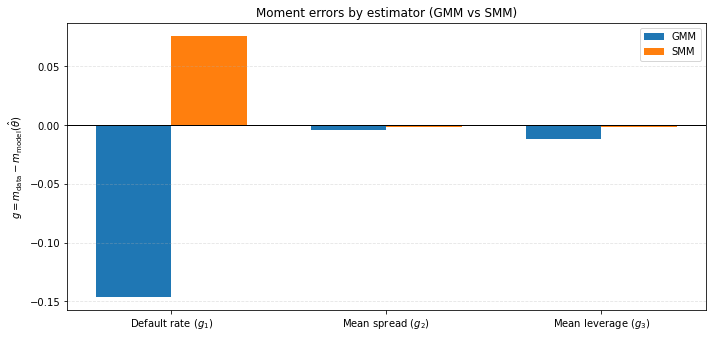

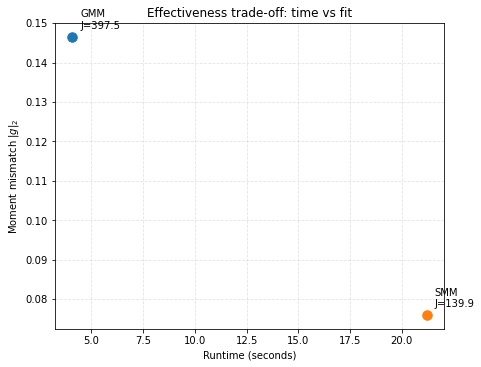

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paste your numbers here ---
results = {
    "GMM": {
        "J": 397.5321350097656,
        "runtime_sec": 4.0765533447265625,
        "g": np.array([-0.1460, -0.00396758, -0.01171750]),
    },
    "SMM": {
        "J": 139.9,  # use your exact final J if you have it
        "runtime_sec": 21.20,
        "g": np.array([0.07600001, -0.00145406, -0.00137132]),
    }
}

moment_names = ["Default rate ($g_1$)", "Mean spread ($g_2$)", "Mean leverage ($g_3$)"]

def main():
    methods = list(results.keys())
    G = np.vstack([results[m]["g"] for m in methods])  # shape (M,3)
    runtimes = np.array([results[m]["runtime_sec"] for m in methods], dtype=float)
    Jvals = np.array([results[m]["J"] for m in methods], dtype=float)

    gnorm = np.linalg.norm(G, axis=1)

    # -------------------------
    # Figure 1: Moment errors
    # -------------------------
    x = np.arange(len(moment_names))
    width = 0.35

    fig1, ax1 = plt.subplots(figsize=(10, 4.8))
    ax1.bar(x - width/2, G[0], width, label=methods[0])
    ax1.bar(x + width/2, G[1], width, label=methods[1])
    ax1.axhline(0.0, color="black", lw=1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(moment_names, rotation=0)
    ax1.set_ylabel(r"$g = m_{\mathrm{data}} - m_{\mathrm{model}}(\hat\theta)$")
    ax1.set_title("Moment errors by estimator (GMM vs SMM)")
    ax1.legend()
    ax1.grid(True, axis="y", ls="--", alpha=0.35)
    fig1.tight_layout()
    fig1.savefig("gmm_smm_moment_errors.png", dpi=200)
    fig1.savefig("gmm_smm_moment_errors.pdf")
    #plt.close(fig1)
    plt.show()

    # -----------------------------------
    # Figure 2: Runtime vs moment mismatch
    # -----------------------------------
    fig2, ax2 = plt.subplots(figsize=(6.8, 5.2))
    for i, m in enumerate(methods):
        ax2.scatter(runtimes[i], gnorm[i], s=90)
        ax2.annotate(
            f"{m}\nJ={Jvals[i]:.1f}",
            (runtimes[i], gnorm[i]),
            textcoords="offset points",
            xytext=(8, 8),
            ha="left",
            fontsize=10
        )
    ax2.set_xlabel("Runtime (seconds)")
    ax2.set_ylabel(r"Moment mismatch $\|g\|_2$")
    ax2.set_title("Effectiveness trade-off: time vs fit")
    ax2.grid(True, ls="--", alpha=0.35)
    fig2.tight_layout()
    fig2.savefig("gmm_smm_tradeoff.png", dpi=200)
    fig2.savefig("gmm_smm_tradeoff.pdf")
    #plt.close(fig2)
    plt.show()

   # print("Saved:")
   # print("  gmm_smm_moment_errors.(png|pdf)")
   # print("  gmm_smm_tradeoff.(png|pdf)")

if __name__ == "__main__":
    main()

# Bonus Question 2 #

In [47]:
# sec36_ceo_board_tf_FIXED.py
# TF2 demo: risky debt + CEO (effort/manipulation/risk) + Board contract
# Fixes:
#  1) sample_states uses TF stateless RNG (works under @tf.function; no NumPy seed Tensor error)
#  2) CEO FOC residuals are computed with y_rep recomputed INSIDE the tape so gradients flow through m and e
#  3) rtilde kept positive via softplus; kp constrained >=0; sig_add bounded
#  4) Small numerical safeties (clip, eps)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import tensorflow as tf

DTYPE = tf.float32
EPS = tf.constant(1e-6, dtype=DTYPE)

# -----------------------------
# Parameters (structural + contract defaults)
# -----------------------------
class Params:
    # preferences / discount
    r = 0.02
    beta = 1.0 / (1.0 + r)

    # production
    theta = 0.7
    delta = 0.12
    phi = 0.01
    chi_eff = 0.3          # effort -> cash flow slope

    # shocks
    rho = 0.7
    sigma_base = 0.12      # baseline vol
    sigma_max_add = 0.35   # how much CEO can increase vol

    # taxes + default costs
    tau = 0.2
    alpha = 0.2

    # CEO action costs / penalties
    kappa_e = 1.0          # effort quadratic cost
    kappa_m = 0.5          # manipulation quadratic cost
    kappa_s = 0.15         # risk choice cost weight
    det_gamma = 2.0        # detection prob sensitivity to m
    det_penalty = 0.3      # expected penalty scale

    # reporting noise
    sigma_y = 0.05

    # bounds
    k_min = 1e-6
    k_max = 200.0
    z_min = 1e-4
    z_max = 50.0

P = Params()

# -----------------------------
# MLP helpers
# -----------------------------
def make_mlp(out_dim, hidden=(256, 256), act="tanh"):
    return tf.keras.Sequential(
        [tf.keras.layers.Dense(h, activation=act) for h in hidden] +
        [tf.keras.layers.Dense(out_dim, activation=None)]
    )

# -----------------------------
# Networks
# -----------------------------
class VNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.mlp = make_mlp(1)

    @tf.function
    def call(self, k, b, z):
        x = tf.concat([k, b, z], axis=1)
        return self.mlp(x)

class FirmPolicyNet(tf.keras.Model):
    """Firm chooses next capital/debt (kp, bp)."""
    def __init__(self):
        super().__init__()
        self.mlp = make_mlp(2)

    @tf.function
    def call(self, k, b, z):
        x = tf.concat([k, b, z], axis=1)
        out = self.mlp(x)
        kp = tf.nn.softplus(out[:, 0:1])
        bp = out[:, 1:2]  # can be +/- (cash or debt)
        kp = tf.clip_by_value(kp, 0.0, P.k_max)
        return kp, bp

class RateNet(tf.keras.Model):
    """Maps (z,kp,bp, signal) to promised yield spread component rtilde."""
    def __init__(self):
        super().__init__()
        self.mlp = make_mlp(1)

    @tf.function
    def call(self, z, kp, bp, y_rep):
        x = tf.concat([z, kp, bp, y_rep], axis=1)
        raw = self.mlp(x)
        rtilde = tf.nn.softplus(raw) - 1e-3  # ensure 1+rtilde>0
        return rtilde

class CEOPolicyNet(tf.keras.Model):
    """CEO chooses effort e>=0, manipulation m (free sign), risk add >=0."""
    def __init__(self):
        super().__init__()
        self.mlp = make_mlp(3)

    @tf.function
    def call(self, k, b, z, contract):
        x = tf.concat([k, b, z, contract], axis=1)
        out = self.mlp(x)

        e = tf.nn.softplus(out[:, 0:1])                # e >= 0
        m = out[:, 1:2]                                # manipulation can be +/-
        sig_add = tf.nn.softplus(out[:, 2:3])          # >=0
        sig_add = tf.clip_by_value(sig_add, 0.0, P.sigma_max_add)

        e = tf.clip_by_value(e, 0.0, 5.0)
        m = tf.clip_by_value(m, -2.0, 2.0)
        return e, m, sig_add

# Board contract parameters (trainable scalars)
# s0: salary, s1: bonus sensitivity to reported performance, s2: convexity (options-like)
s0 = tf.Variable(0.1, dtype=DTYPE, trainable=True, name="s0")
s1 = tf.Variable(0.2, dtype=DTYPE, trainable=True, name="s1")
s2 = tf.Variable(0.1, dtype=DTYPE, trainable=True, name="s2")
ybar = tf.constant(0.0, dtype=DTYPE)  # option threshold

V = VNet()
FirmPol = FirmPolicyNet()
Rate = RateNet()
CEO = CEOPolicyNet()

# -----------------------------
# Economic primitives
# -----------------------------
@tf.function
def pi_true(k, z, e):
    k = tf.clip_by_value(k, P.k_min, P.k_max)
    z = tf.clip_by_value(z, P.z_min, P.z_max)
    return z * tf.pow(k, P.theta) + P.chi_eff * e

@tf.function
def adj_cost(I):
    return 0.5 * P.phi * tf.square(I)

@tf.function
def ceo_cost(e, m, sig_add):
    ce = 0.5 * P.kappa_e * tf.square(e)
    cm = 0.5 * P.kappa_m * tf.square(m)
    cs = 0.5 * P.kappa_s * tf.square(sig_add)
    # detection prob and expected penalty from manipulation
    p_det = tf.sigmoid(P.det_gamma * m)
    pen = P.det_penalty * p_det
    return ce + cm + cs + pen, p_det

@tf.function
def ceo_pay(y_rep, s0v, s1v, s2v):
    # pay = salary + linear + convex bonus
    bonus_convex = tf.nn.relu(y_rep - ybar)
    return s0v + s1v * y_rep + s2v * bonus_convex

# -----------------------------
# TF-friendly state sampling (stateless RNG)
# -----------------------------
@tf.function
def sample_states(B, seed2):
    """
    B: Python int or scalar int tensor
    seed2: int32[2] stateless seed
    """
    seed2 = tf.cast(seed2, tf.int32)

    uk = tf.random.stateless_uniform([B, 1], seed=seed2, minval=-2.0, maxval=4.5, dtype=DTYPE)
    uz = tf.random.stateless_uniform([B, 1], seed=seed2 + tf.constant([1, 0], tf.int32),
                                     minval=-1.0, maxval=1.0, dtype=DTYPE)
    ub = tf.random.stateless_uniform([B, 1], seed=seed2 + tf.constant([2, 0], tf.int32),
                                     minval=-20.0, maxval=50.0, dtype=DTYPE)

    k = tf.clip_by_value(tf.exp(uk), P.k_min, P.k_max)
    z = tf.clip_by_value(tf.exp(uz), P.z_min, P.z_max)
    b = ub
    return k, b, z

@tf.function
def sample_z_next(z, sig_add, n_mc):
    z = tf.clip_by_value(z, P.z_min, P.z_max)
    sigma_eff = P.sigma_base + sig_add                        # [B,1]
    eps = tf.random.normal([tf.shape(z)[0], n_mc], 0.0, 1.0, dtype=DTYPE)
    logz_next = P.rho * tf.math.log(z) + sigma_eff * eps       # broadcast sigma_eff over MC dim
    z_next = tf.exp(logz_next)
    return tf.clip_by_value(z_next, P.z_min, P.z_max)

# -----------------------------
# Residual system
# -----------------------------
@tf.function
def residuals(k, b, z, n_mc):
    beta = tf.constant(P.beta, DTYPE)

    # Board contract broadcast
    contract = tf.concat(
        [tf.ones_like(k) * s0, tf.ones_like(k) * s1, tf.ones_like(k) * s2],
        axis=1
    )

    # CEO actions
    e, m, sig_add = CEO(k, b, z, contract)

    # Firm policies
    V_now = V(k, b, z)
    kp, bp = FirmPol(k, b, z)
    I = kp - (1.0 - P.delta) * k

    # ---------- Reported signal (outside tape, used for pricing/Bellman) ----------
    pi = pi_true(k, z, e)
    y_noise = tf.random.normal(tf.shape(pi), 0.0, P.sigma_y, dtype=DTYPE)
    y_rep = tf.math.log(pi + EPS) + m + y_noise

    rtilde = Rate(z, kp, bp, y_rep)

    # CEO pay/cost (realized)
    cost_ceo, p_det = ceo_cost(e, m, sig_add)
    w = ceo_pay(y_rep, s0, s1, s2)

    # equity flow
    flow = (1.0 - P.tau) * pi - I - adj_cost(I) - w + bp / (1.0 + rtilde) - b

    # expectation over z'
    z_next = sample_z_next(z, sig_add, n_mc)                   # [B,M]
    kp_mc = tf.tile(kp, [1, n_mc])
    bp_mc = tf.tile(bp, [1, n_mc])

    V_next = V(tf.reshape(kp_mc, [-1, 1]),
               tf.reshape(bp_mc, [-1, 1]),
               tf.reshape(z_next, [-1, 1]))
    V_next = tf.reshape(V_next, [-1, n_mc])
    EV_next = tf.reduce_mean(V_next, axis=1, keepdims=True)

    cont = flow + beta * EV_next
    V_target = tf.nn.relu(cont)
    R_bell = V_now - V_target

    # default & pricing
    temp = tf.constant(1.0, DTYPE)
    p_def = tf.sigmoid(-cont / temp)
    p_sol = 1.0 - p_def

    rec = (1.0 - P.alpha) * (
        (1.0 - P.tau) * pi_true(kp, z, tf.zeros_like(e)) + (1.0 - P.delta) * kp
    )

    lhs = bp * (1.0 + P.r)
    rhs = p_def * rec + p_sol * bp * (1.0 + rtilde)
    R_price = lhs - rhs

    # ---------- CEO FOC residuals (recompute y_rep INSIDE tape) ----------
    # This ensures gradients flow through e, m, sig_add to U via pi -> y_rep -> pay and cost.
    # Note: keep the same realized y_noise for consistency (treated as exogenous wrt CEO choice).
    with tf.GradientTape() as tape:
        tape.watch([e, m, sig_add])

        pi2 = pi_true(k, z, e)
        y_rep2 = tf.math.log(pi2 + EPS) + m + y_noise           # recomputed inside tape

        w2 = ceo_pay(y_rep2, s0, s1, s2)
        cost2, _ = ceo_cost(e, m, sig_add)
        U = w2 - cost2

    dU_de, dU_dm, dU_dsig = tape.gradient(U, [e, m, sig_add])

    # Replace None gradients with zeros (can happen at kinks like ReLU; softplus helps, but be safe)
    dU_de = tf.zeros_like(e) if dU_de is None else dU_de
    dU_dm = tf.zeros_like(m) if dU_dm is None else dU_dm
    dU_dsig = tf.zeros_like(sig_add) if dU_dsig is None else dU_dsig

    R_ceo = tf.concat([dU_de, dU_dm, dU_dsig], axis=1)

    aux = {
        "cont": cont,
        "p_def": p_def,
        "rtilde": rtilde,
        "e": e,
        "m": m,
        "sig_add": sig_add,
        "pay": w,
        "p_det": p_det,
        "y_rep": y_rep,
        "s0": s0, "s1": s1, "s2": s2,
    }
    return R_bell, R_price, R_ceo, aux

@tf.function
def loss(k, b, z, n_mc, w_price=0.2, w_ceo=0.1):
    Rb, Rp, Rceo, aux = residuals(k, b, z, n_mc)
    Lb = tf.reduce_mean(tf.square(Rb))
    Lp = tf.reduce_mean(tf.square(Rp))
    Lceo = tf.reduce_mean(tf.square(Rceo))
    L = Lb + w_price * Lp + w_ceo * Lceo
    return L, Lb, Lp, Lceo, aux

# -----------------------------
# Training + evaluation
# -----------------------------
def train(steps=6000, B=4096, n_mc=16, lr=2e-4, seed=0, w_price=0.2, w_ceo=0.1, print_every=500):
    opt = tf.keras.optimizers.Adam(lr)

    # build (one forward pass)
    k0, b0, z0 = sample_states(4, tf.constant([seed, 1], tf.int32))
    contract0 = tf.concat([tf.ones_like(k0)*s0, tf.ones_like(k0)*s1, tf.ones_like(k0)*s2], axis=1)
    _ = V(k0, b0, z0)
    _ = FirmPol(k0, b0, z0)
    _ = CEO(k0, b0, z0, contract0)
    _ = Rate(z0, k0, b0, tf.zeros_like(k0))

    for t in range(1, steps + 1):
        k, b, z = sample_states(B, tf.constant([seed, t], tf.int32))

        with tf.GradientTape() as tape:
            L, Lb, Lp, Lceo, aux = loss(k, b, z, n_mc, w_price=w_price, w_ceo=w_ceo)

        vars_ = (
            V.trainable_variables +
            FirmPol.trainable_variables +
            CEO.trainable_variables +
            Rate.trainable_variables +
            [s0, s1, s2]
        )

        grads = tape.gradient(L, vars_)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        opt.apply_gradients(zip(grads, vars_))

        if t % print_every == 0 or t == 1:
            print(
                f"step {t:6d} | total {float(L):.3e} | bell {float(Lb):.3e} | price {float(Lp):.3e} | ceoFOC {float(Lceo):.3e} "
                f"| mean p_def {float(tf.reduce_mean(aux['p_def'])):.3f} | mean rtilde {float(tf.reduce_mean(aux['rtilde'])):.3f} "
                f"| mean e {float(tf.reduce_mean(aux['e'])):.3f} | mean m {float(tf.reduce_mean(aux['m'])):.3f} | mean sig_add {float(tf.reduce_mean(aux['sig_add'])):.3f} "
                f"| contract (s0,s1,s2)=({float(s0):.3f},{float(s1):.3f},{float(s2):.3f})"
            )

def evaluate(B=15000, n_mc=256, seed=999):
    k, b, z = sample_states(B, tf.constant([seed, 1], tf.int32))
    Rb, Rp, Rceo, aux = residuals(k, b, z, n_mc=n_mc)

    bell_rmse = float(tf.sqrt(tf.reduce_mean(tf.square(Rb))))
    price_rmse = float(tf.sqrt(tf.reduce_mean(tf.square(Rp))))
    ceo_rmse = float(tf.sqrt(tf.reduce_mean(tf.square(Rceo))))

    print(f"[EVAL] Bellman RMSE: {bell_rmse:.4e} | Pricing RMSE: {price_rmse:.4e} | CEO FOC RMSE: {ceo_rmse:.4e}")
    print(f"[EVAL] mean default prob: {float(tf.reduce_mean(aux['p_def'])):.3f} | mean p_det: {float(tf.reduce_mean(aux['p_det'])):.3f}")
    print(f"[EVAL] mean pay: {float(tf.reduce_mean(aux['pay'])):.3f} | mean y_rep: {float(tf.reduce_mean(aux['y_rep'])):.3f}")

if __name__ == "__main__":
    tf.random.set_seed(0)
    np.random.seed(0)

    train()
    evaluate()

step      1 | total 3.651e+02 | bell 3.651e+02 | price 2.392e-01 | ceoFOC 3.220e-01 | mean p_def 0.545 | mean rtilde 0.686 | mean e 0.838 | mean m -0.093 | mean sig_add 0.350 | contract (s0,s1,s2)=(0.100,0.200,0.100)
step    500 | total 2.482e+00 | bell 2.087e+00 | price 1.892e+00 | ceoFOC 1.727e-01 | mean p_def 0.469 | mean rtilde 0.356 | mean e 0.294 | mean m 0.710 | mean sig_add 0.350 | contract (s0,s1,s2)=(0.143,0.251,0.150)
step   1000 | total 7.894e-01 | bell 6.243e-01 | price 7.789e-01 | ceoFOC 9.247e-02 | mean p_def 0.423 | mean rtilde 0.256 | mean e 0.151 | mean m 0.965 | mean sig_add 0.253 | contract (s0,s1,s2)=(0.150,0.258,0.157)
step   1500 | total 3.940e-01 | bell 3.057e-01 | price 4.032e-01 | ceoFOC 7.580e-02 | mean p_def 0.406 | mean rtilde 0.379 | mean e 0.156 | mean m 1.177 | mean sig_add 0.219 | contract (s0,s1,s2)=(0.153,0.262,0.161)
step   2000 | total 2.399e-01 | bell 1.865e-01 | price 2.291e-01 | ceoFOC 7.649e-02 | mean p_def 0.397 | mean rtilde 0.552 | mean e 0.1

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    # step, total, bell, price, ceoFOC, p_def, rtilde, e, m, sig_add, s0, s1, s2
    (1,    365.1, 365.1, 0.2392, 0.3220, 0.545, 0.686, 0.838, -0.093, 0.350, 0.100, 0.200, 0.100),
    (500,    2.482, 2.087, 1.892, 0.1727, 0.469, 0.356, 0.294,  0.710, 0.350, 0.143, 0.251, 0.150),
    (1000,   0.7894, 0.6243, 0.7789, 0.09247,0.423, 0.256, 0.151,  0.965, 0.253, 0.150, 0.258, 0.157),
    (1500,   0.3940, 0.3057, 0.4032, 0.07580,0.406, 0.379, 0.156,  1.177, 0.219, 0.153, 0.262, 0.161),
    (2000,   0.2399, 0.1865, 0.2291, 0.07649,0.397, 0.552, 0.148,  1.119, 0.215, 0.155, 0.265, 0.164),
    (2500,   0.2296, 0.1813, 0.2077, 0.06774,0.408, 0.716, 0.138,  1.153, 0.210, 0.157, 0.267, 0.166),
    (3000,   0.2043, 0.1722, 0.1279, 0.06517,0.386, 0.955, 0.132,  1.218, 0.216, 0.158, 0.270, 0.168),
    (3500,   0.1433, 0.1123, 0.1250, 0.06068,0.398, 1.185, 0.121,  1.251, 0.214, 0.159, 0.273, 0.171),
    (4000,   0.08611,0.05827,0.1090, 0.06038,0.395, 1.316, 0.118,  1.260, 0.215, 0.160, 0.276, 0.174),
    (4500,   0.2154, 0.1931, 0.08317,0.05730,0.401, 1.547, 0.119,  1.226, 0.209, 0.160, 0.279, 0.176),
    (5000,   0.1277, 0.1018, 0.1010, 0.05679,0.407, 1.520, 0.114,  1.251, 0.208, 0.161, 0.282, 0.178),
    (5500,   0.1111, 0.09108,0.07223,0.05576,0.387, 1.588, 0.106,  1.255, 0.215, 0.162, 0.286, 0.182),
    (6000,   0.07485,0.05664,0.06471,0.05265,0.398, 1.706, 0.112,  1.222, 0.210, 0.162, 0.290, 0.185),
]

cols = ["step","total","bell","price","ceoFOC","p_def","rtilde","e","m","sig_add","s0","s1","s2"]
df = pd.DataFrame(data, columns=cols)

df.head()

,step,total,bell,price,ceoFOC,p_def,rtilde,e,m,sig_add,s0,s1,s2
0,1,365.1000,365.1000,0.2392,0.32200,0.545,0.686,0.838,-0.093,0.350,0.100,0.200,0.100
1,500,2.4820,2.0870,1.8920,0.17270,0.469,0.356,0.294,0.710,0.350,0.143,0.251,0.150
2,1000,0.7894,0.6243,0.7789,0.09247,0.423,0.256,0.151,0.965,0.253,0.150,0.258,0.157
3,1500,0.3940,0.3057,0.4032,0.07580,0.406,0.379,0.156,1.177,0.219,0.153,0.262,0.161
4,2000,0.2399,0.1865,0.2291,0.07649,0.397,0.552,0.148,1.119,0.215,0.155,0.265,0.164


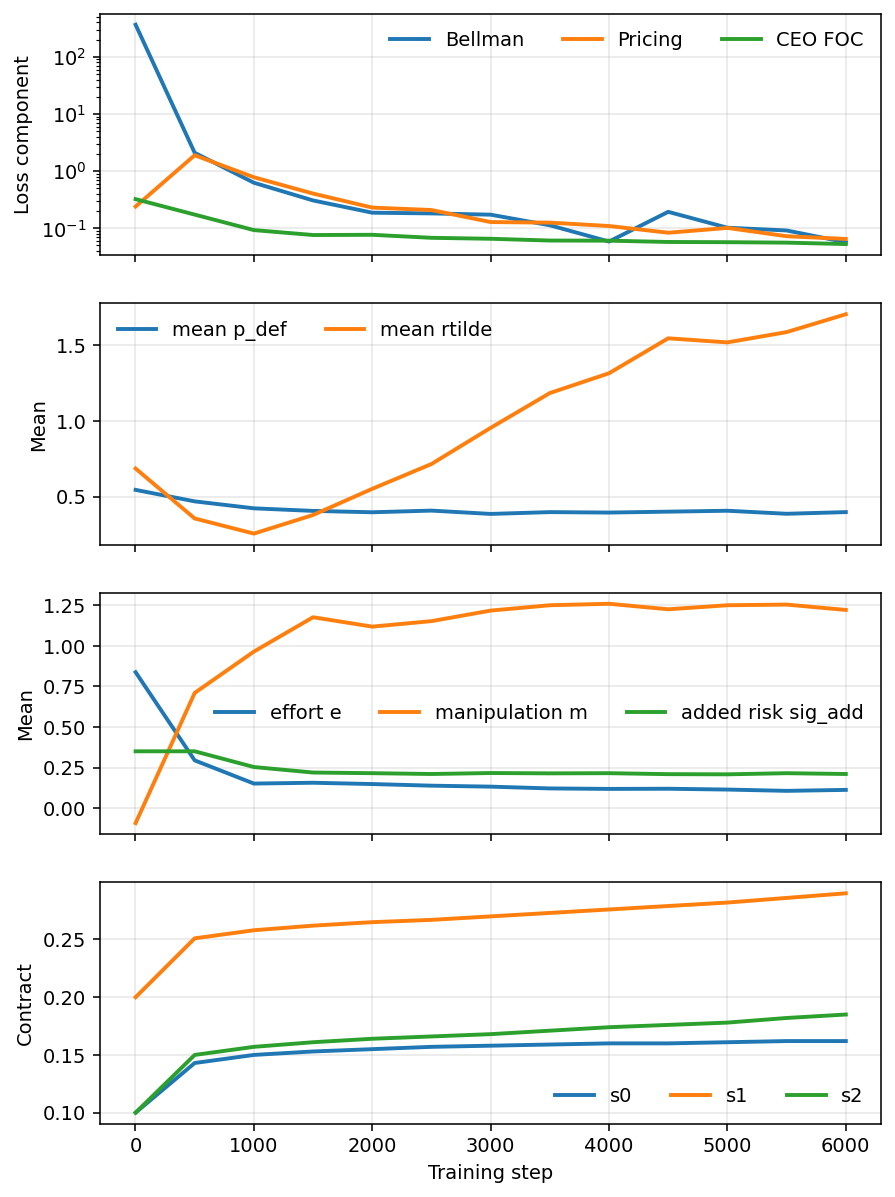

In [50]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.bbox": "tight",
    "font.size": 10
})

fig, axs = plt.subplots(4, 1, figsize=(7.2, 10.5), sharex=True)

# Panel 1: residual components
axs[0].plot(df["step"], df["bell"], label="Bellman", lw=2)
axs[0].plot(df["step"], df["price"], label="Pricing", lw=2)
axs[0].plot(df["step"], df["ceoFOC"], label="CEO FOC", lw=2)
axs[0].set_ylabel("Loss component")
axs[0].set_yscale("log")  # important because Bellman starts huge
axs[0].grid(True, alpha=0.3)
axs[0].legend(ncol=3, frameon=False)

# Panel 2: credit outcomes
axs[1].plot(df["step"], df["p_def"], label="mean p_def", lw=2)
axs[1].plot(df["step"], df["rtilde"], label="mean rtilde", lw=2)
axs[1].set_ylabel("Mean")
axs[1].grid(True, alpha=0.3)
axs[1].legend(ncol=2, frameon=False)

# Panel 3: CEO actions
axs[2].plot(df["step"], df["e"], label="effort e", lw=2)
axs[2].plot(df["step"], df["m"], label="manipulation m", lw=2)
axs[2].plot(df["step"], df["sig_add"], label="added risk sig_add", lw=2)
axs[2].set_ylabel("Mean")
axs[2].grid(True, alpha=0.3)
axs[2].legend(ncol=3, frameon=False)

# Panel 4: contract parameters
axs[3].plot(df["step"], df["s0"], label="s0", lw=2)
axs[3].plot(df["step"], df["s1"], label="s1", lw=2)
axs[3].plot(df["step"], df["s2"], label="s2", lw=2)
axs[3].set_ylabel("Contract")
axs[3].set_xlabel("Training step")
axs[3].grid(True, alpha=0.3)
axs[3].legend(ncol=3, frameon=False)

fig.suptitle("Training diagnostics (losses, credit outcomes, CEO actions, contract path)", y=0.995)
#plt.savefig("training_diagnostics.pdf")
plt.show()